In [1]:
import sys
sys.path.append("/workspace/mta_vision_transformers/")
from collections import OrderedDict
from typing import Any, Callable, Dict, List, Set, Tuple

import numpy as np
import einops
import torch
import torch.nn as nn
import torch.nn.functional as Fn
import torch.utils.data
from matplotlib import pyplot as plt
from tensordict import TensorDict
from torch.utils._pytree import tree_flatten

from infrastructure import utils
from infrastructure.settings import DEVICE, OUTPUT_DEVICE, DTYPE
from dataset.construct import ImageDataset
from dataset.library import DATASETS

from core.monitor import Monitor


dataset_name, n_classes = DATASETS["Common"][1]
    
# Ocean: 901085904
# Rose: 100390212
torch.set_printoptions(linewidth=400, sci_mode=False)

Seed: 1149496617


In [2]:
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
from modeling.openclip_attention import OpenCLIPViT
from core.visualize import construct_per_layer_output_dict

base_model_name = "openai/clip-vit-large-patch14"


# SECTION: Set up model
model = OpenCLIPViT(0, None, "default").to(DEVICE)


# SECTION: Set up monitor
def residual_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return input_ + tree_flatten(output_)[0][0]
    
def input_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return tree_flatten(input_)[0][0]

def attention_matrix_hook_fn(model_: nn.Module, input_: Any, output_: Any) -> Any:
    return einops.rearrange(
        tree_flatten(output_)[0][0],
        "b h n1 n2 -> b n1 n2 h"
    ).to(OUTPUT_DEVICE)


monitor_config = OrderedDict({
    "_model.visual.transformer.resblocks": OrderedDict({
        "": [
            # ("layer_input", input_hook_fn),
            ("layer_output", Monitor.default_hook_fn),
        ],
        # "ln_1": "layer_norm1_output",  # "norm1"
        "return_attn_matrix": [
            ("attention_matrix", attention_matrix_hook_fn)
        ],
        "attn": [
            # ("attention_input", input_hook_fn),
            # ("query", query_hook_fn),
            # ("key", key_hook_fn),
            # ("attention_proj", attention_proj_hook_fn),
            # ("attention_output", Monitor.default_hook_fn),
            # ("attention_matrix", attention_matrix_hook_fn),
        ],
    })
})

monitor = Monitor(model, monitor_config)


# SECTION: Set up dataset 
image_processor = CLIPImageProcessor.from_pretrained(base_model_name)
transform = lambda images: image_processor(images=images, return_tensors="pt")["pixel_values"].squeeze(0)

batch_size = 50
dataset = ImageDataset(dataset_name, transform, split="train", return_original_image=True)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator(DEVICE))
original_images, images = next(iter(dataloader))


# SECTION: Run baseline model
torch.set_default_device(DEVICE)
per_metric_output_dict = monitor.reset()
with torch.no_grad():
    output = model.forward(images)

per_layer_output_dict = construct_per_layer_output_dict(per_metric_output_dict)

	Image 0 --- incoming attention: [-2.060994863510132, -2.4139597415924072, -4.6029052734375, -4.752785682678223, -4.7990193367004395, -4.86231803894043, -4.886721611022949, -4.92446231842041, -4.928530216217041, -5.012542724609375]
	normalized incoming attention: [6.9874420166015625, 6.336524486541748, 2.299794912338257, 2.0233938694000244, 1.938132405281067, 1.82140052318573, 1.7763968706130981, 1.7067975997924805, 1.6992958784103394, 1.5443646907806396]
	Image 1 --- incoming attention: [-2.0606722831726074, -2.718848705291748, -2.890472650527954, -4.615252494812012, -4.637160778045654, -4.709531307220459, -4.767173767089844, -4.866732120513916, -4.904786586761475, -4.95139741897583]
	normalized incoming attention: [5.951699733734131, 4.937286853790283, 4.67277193069458, 2.0144600868225098, 1.980694055557251, 1.8691532611846924, 1.780311942100525, 1.6268678903579712, 1.5682165622711182, 1.4963778257369995]
	Image 2 --- incoming attention: [-2.191895008087158, -2.3103013038635254, -3.6

/tmp/ipykernel_11671/3663868501.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  "Artifact": torch.load("sandbox/artifact_mask.pt", map_location=OUTPUT_DEVICE)


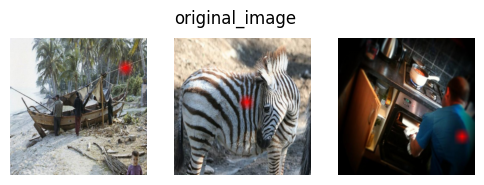

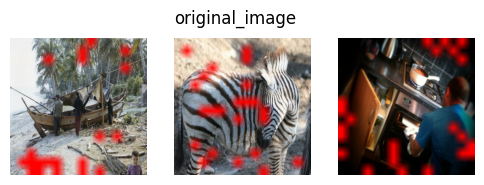

/tmp/ipykernel_11671/3663868501.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  highlight = torch.load("./sandbox/artifact_indices.pt")


In [3]:
# SECTION: Visualize original images
%matplotlib inline
from modeling.image_features import ImageFeatures
from core.attention_sink import mask_attention_sink
from core.visualize import (
    num_visualized_images,
    visualize_images_with_mta,
    get_rgb_colors,
)

torch.set_default_device(OUTPUT_DEVICE)

# SECTION: Massive token heuristic
detection_layer = 13


mta_masks: Dict[int, torch.Tensor] = {
    "MA": mask_attention_sink(per_layer_output_dict[detection_layer]["attention_matrix"], verbose=True),
    "Artifact": torch.load("sandbox/artifact_mask.pt", map_location=OUTPUT_DEVICE)
}

for k, v in mta_masks.items():
    print(f"{k}: {v.sum().item()}/{v.numel()}")

features = ImageFeatures(per_layer_output_dict, mta_masks, "default", DEVICE)


# SECTION: Visualize images
for mask in mta_masks.values():
    visualize_images_with_mta(original_images.to(OUTPUT_DEVICE), mask.to(OUTPUT_DEVICE))

try:
    rgb_assignment
except NameError:
    color_layer_idx = 10    # min(mta_masks.keys())
    rgb_assignment = get_rgb_colors(features, color_layer_idx, "layer_output", False)

# highlight = torch.LongTensor((
#     (1, 5, 4),
#     (4, 15, 8),
# ))
highlight = torch.load("./sandbox/artifact_indices.pt")

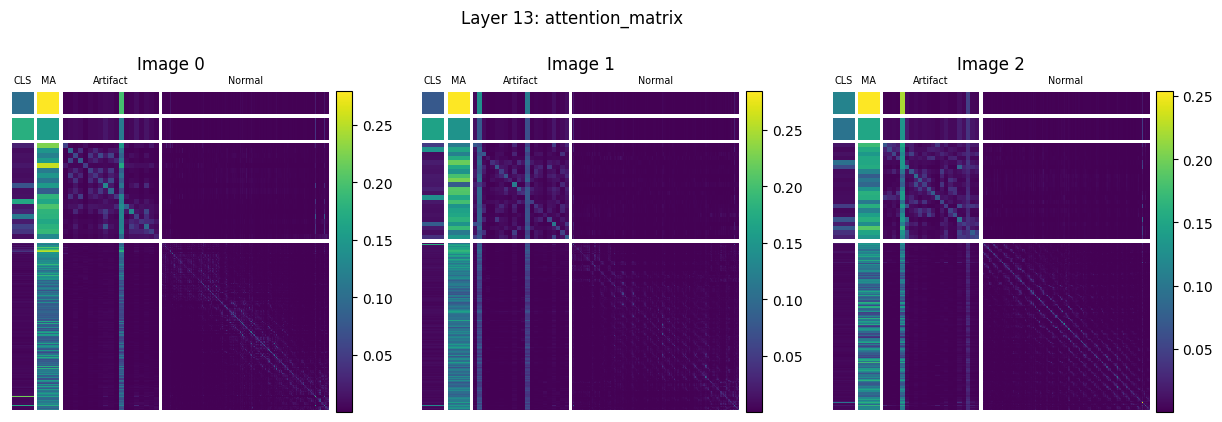

Iteration 1: □□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□
	Image 0 --- incoming attention: [-1.9394237995147705, -3.085020065307617, -3.4591712951660156, -4.6999101638793945, -4.75908899307251, -4.796009540557861, -4.908928871154785, -4.920353889465332, -4.975175857543945, -4.9908766746521]
	normalized incoming attention: [7.11361837387085, 5.023085117340088, 4.340317726135254, 2.0761640071868896, 1.9681719541549683, 1.900797724723816, 1.6947376728057861, 1.673888921737671, 1.5738474130630493, 1.5451958179473877]
	Image 1 --- incoming attention: [-2.2110981941223145, -2.38339900970459, -3.4687838554382324, -3.676496744155884, -4.633800506591797, -4.710107803344727, -4.755357265472412, -4.833462238311768, -4.893786907196045, -4.9546685218811035]
	normalized incoming attention: [5.743620872497559, 5.476120471954346, 3.7910373210906982, 3.4685587882995605, 1.9823243618011475, 1.8638557195663452, 1.7936049699783325, 1.6723453998565674, 1.5786900520324707, 1.4841700792312622]
	Image 2

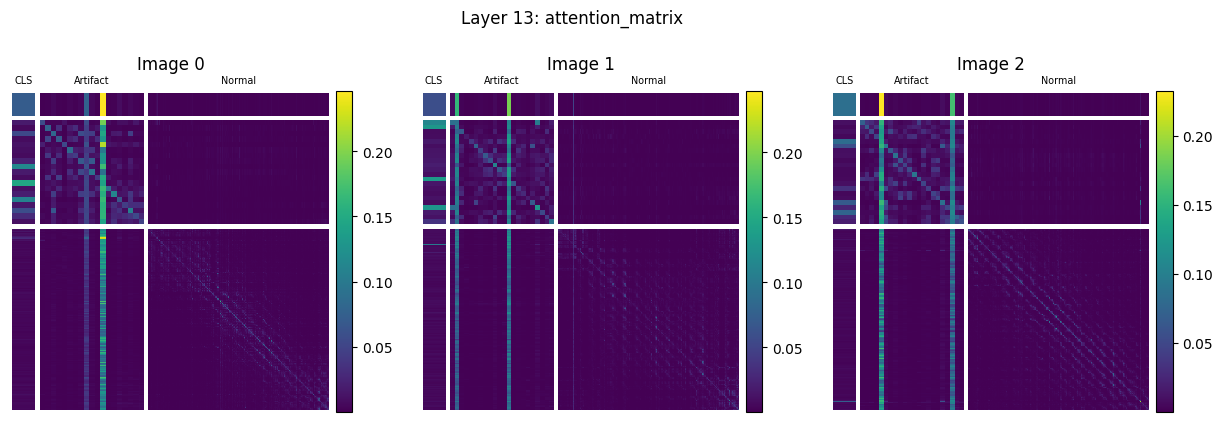

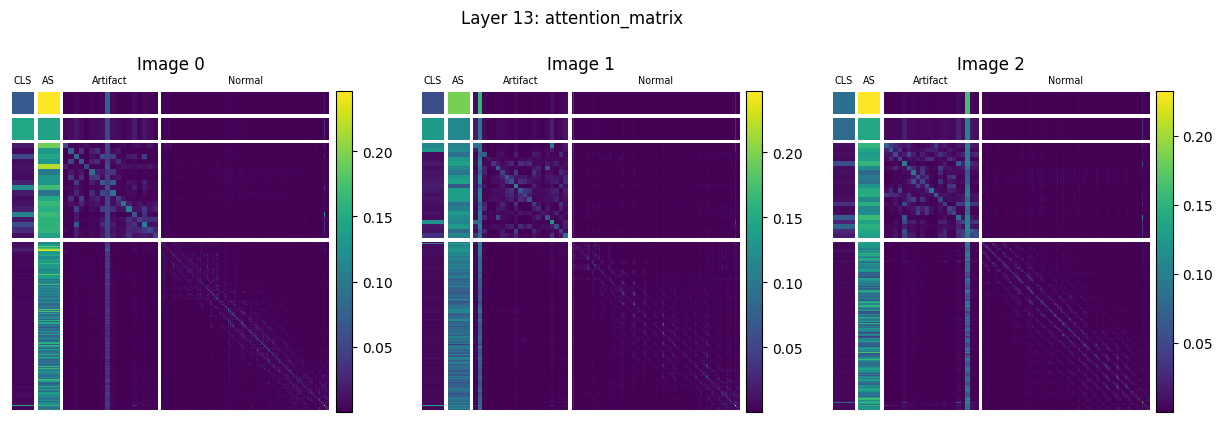

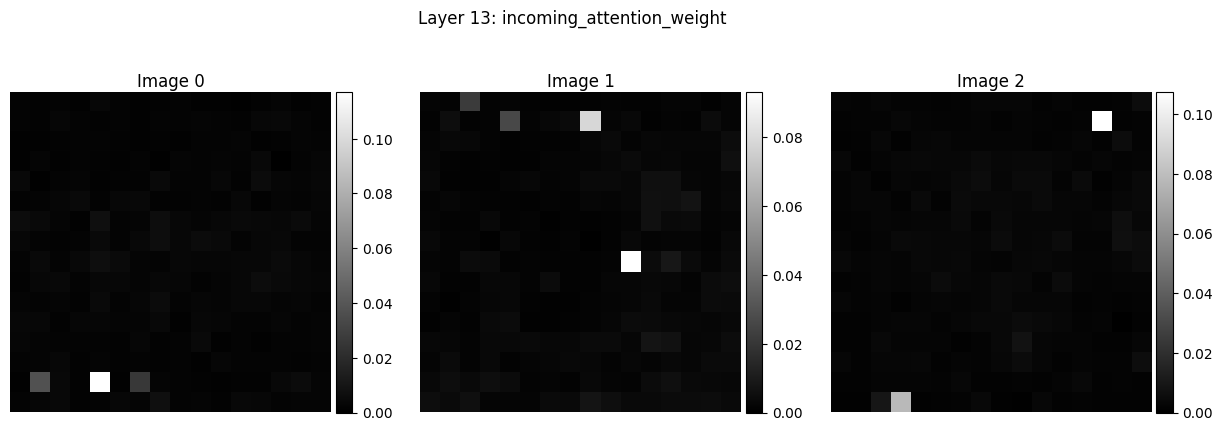

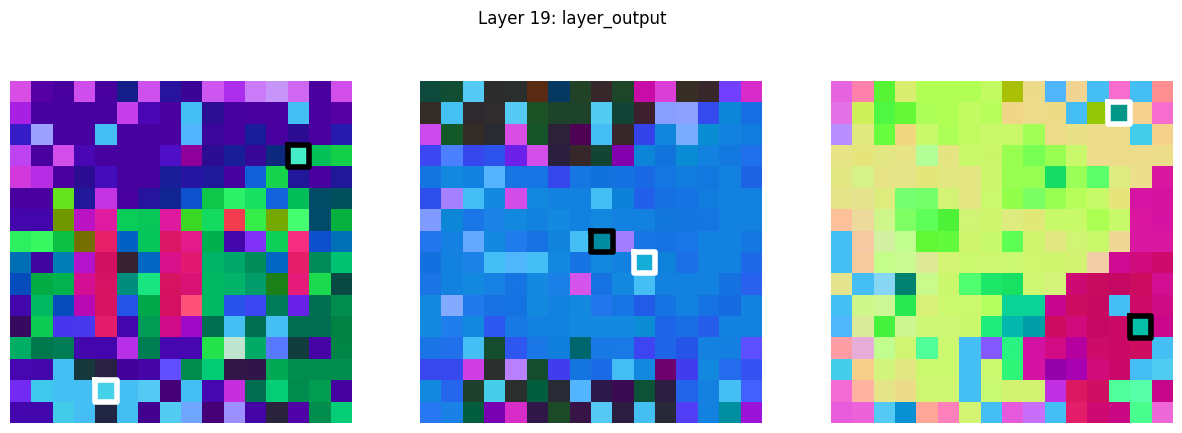

Iteration 2: □□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□
	Image 0 --- incoming attention: [-2.106740713119507, -2.4051883220672607, -4.701828956604004, -4.764244556427002, -4.797565460205078, -4.854233741760254, -4.913212299346924, -4.913629531860352, -4.977639198303223, -4.9970808029174805]
	normalized incoming attention: [6.878256797790527, 6.327667713165283, 2.0907225608825684, 1.9755754470825195, 1.9141035079956055, 1.8095593452453613, 1.700753092765808, 1.6999833583831787, 1.5818954706192017, 1.546028733253479]
	Image 1 --- incoming attention: [-2.2539846897125244, -2.600390911102295, -2.8106584548950195, -4.647270679473877, -4.710553169250488, -4.743860721588135, -4.808964252471924, -4.881202697753906, -4.934235095977783, -4.959117412567139]
	normalized incoming attention: [5.777009963989258, 5.226668834686279, 4.892612934112549, 1.9747562408447266, 1.874218225479126, 1.821302056312561, 1.7178709506988525, 1.6031044721603394, 1.5188510417938232, 1.4793200492858887]
	Image 

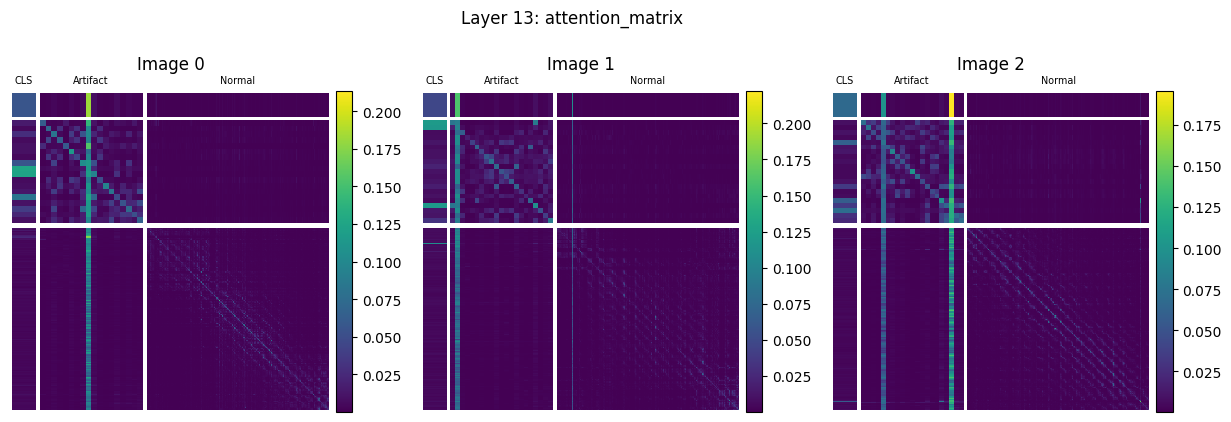

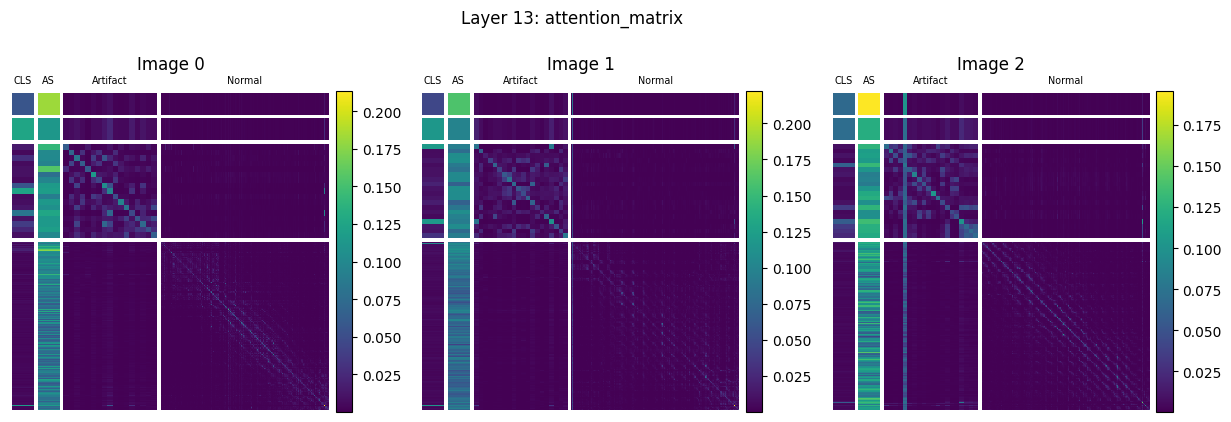

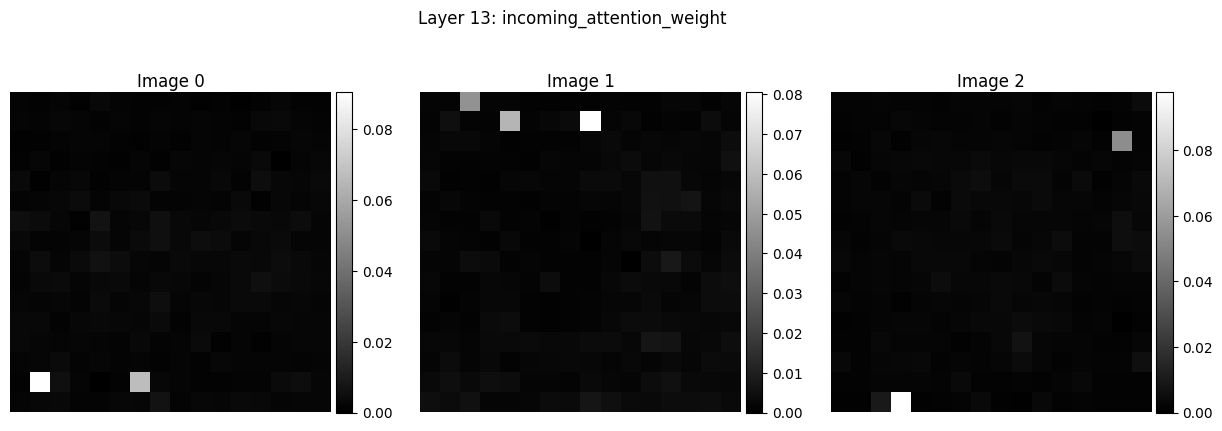

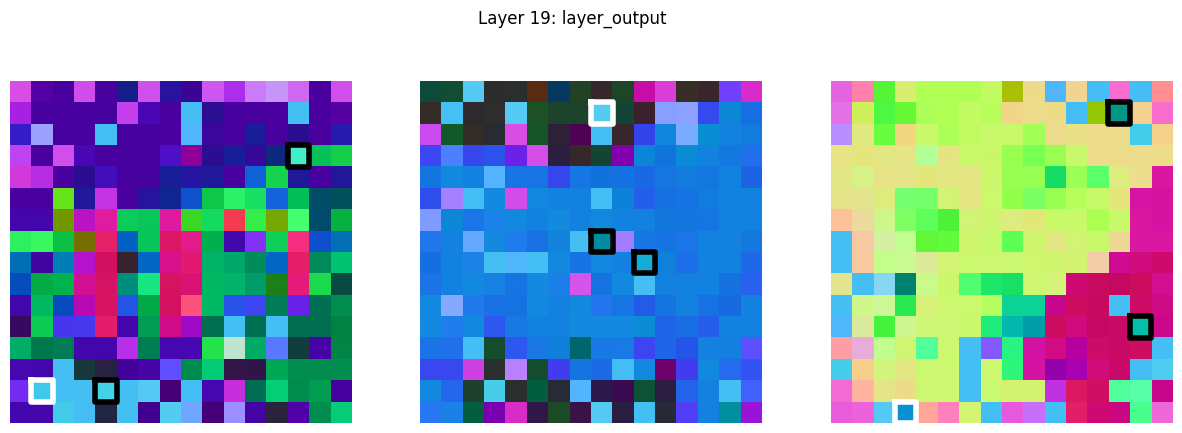

Iteration 3: □□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□
	Image 0 --- incoming attention: [-2.2056210041046143, -2.348865509033203, -4.699605941772461, -4.76417875289917, -4.788934230804443, -4.8757476806640625, -4.899095058441162, -4.912929534912109, -4.959214210510254, -4.984509468078613]
	normalized incoming attention: [6.709780216217041, 6.444036483764648, 2.082998752593994, 1.9632047414779663, 1.9172790050506592, 1.7562247514724731, 1.7129112482070923, 1.6872458457946777, 1.601379632949829, 1.5544525384902954]
	Image 1 --- incoming attention: [-2.215668201446533, -2.2879419326782227, -4.638707637786865, -4.661718368530273, -4.740110397338867, -4.792460918426514, -4.855964660644531, -4.86978006362915, -4.885727405548096, -4.9175872802734375]
	normalized incoming attention: [6.077328681945801, 5.9568305015563965, 2.037534236907959, 1.9991698265075684, 1.8684712648391724, 1.781190276145935, 1.67531418800354, 1.652280569076538, 1.6256924867630005, 1.572574257850647]
	Image 2 --

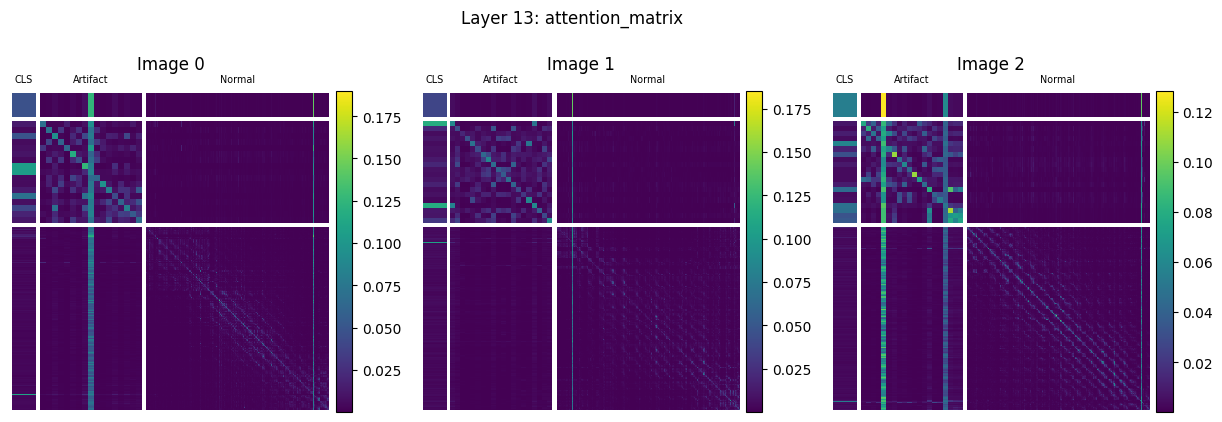

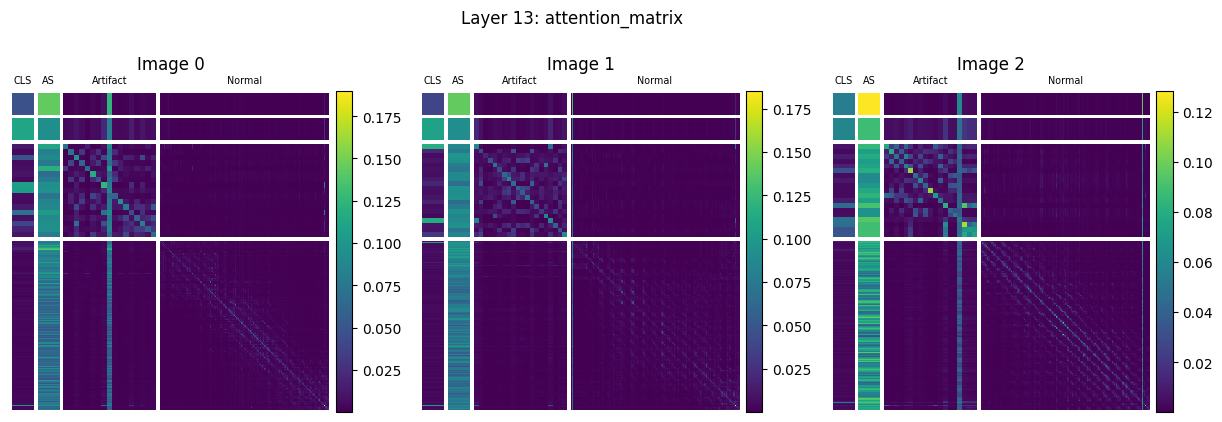

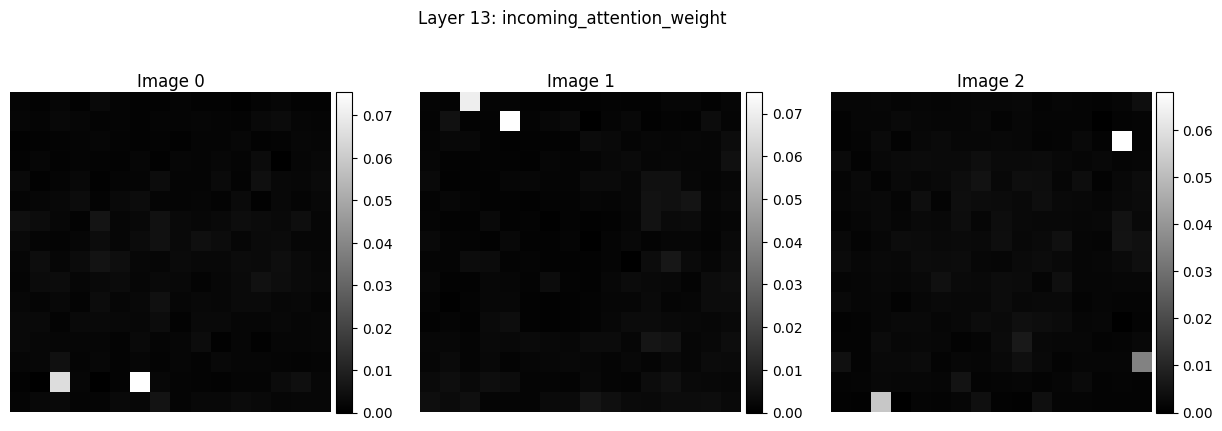

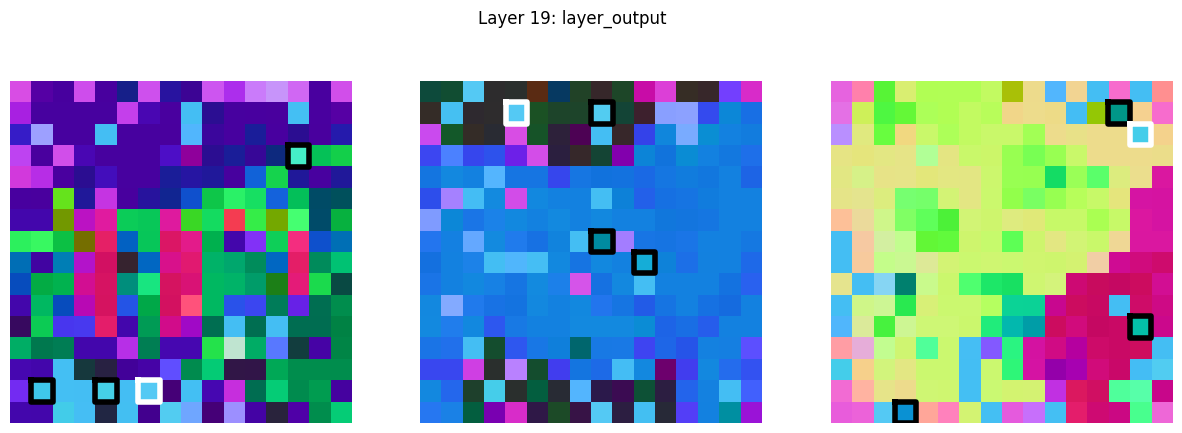

Iteration 4: □□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□
	Image 0 --- incoming attention: [-2.197939872741699, -2.8130006790161133, -3.2625184059143066, -4.686183452606201, -4.765148639678955, -4.785645484924316, -4.895633697509766, -4.912772178649902, -4.949132919311523, -4.9796905517578125]
	normalized incoming attention: [6.592194080352783, 5.469119548797607, 4.648319721221924, 2.0487685203552246, 1.9045815467834473, 1.8671551942825317, 1.6663213968276978, 1.635027289390564, 1.5686341524124146, 1.5128371715545654]
	Image 1 --- incoming attention: [-2.130725145339966, -3.039496660232544, -3.6063780784606934, -4.087690830230713, -4.606034278869629, -4.674990177154541, -4.748828887939453, -4.7891435623168945, -4.860256195068359, -4.874452590942383]
	normalized incoming attention: [6.1895976066589355, 4.668281078338623, 3.7193007469177246, 2.9135656356811523, 2.045839786529541, 1.9304050207138062, 1.8067963123321533, 1.7393081188201904, 1.620262861251831, 1.596497654914856]
	Imag

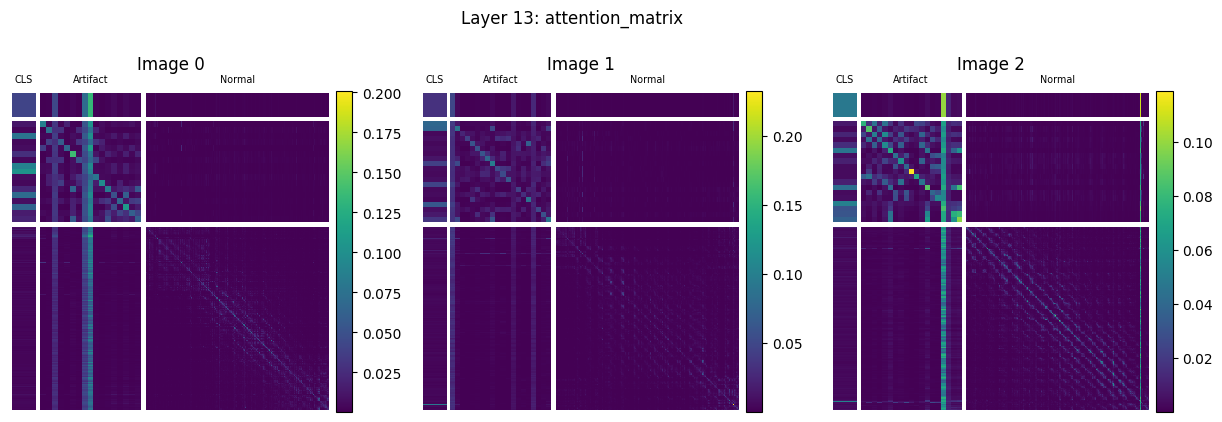

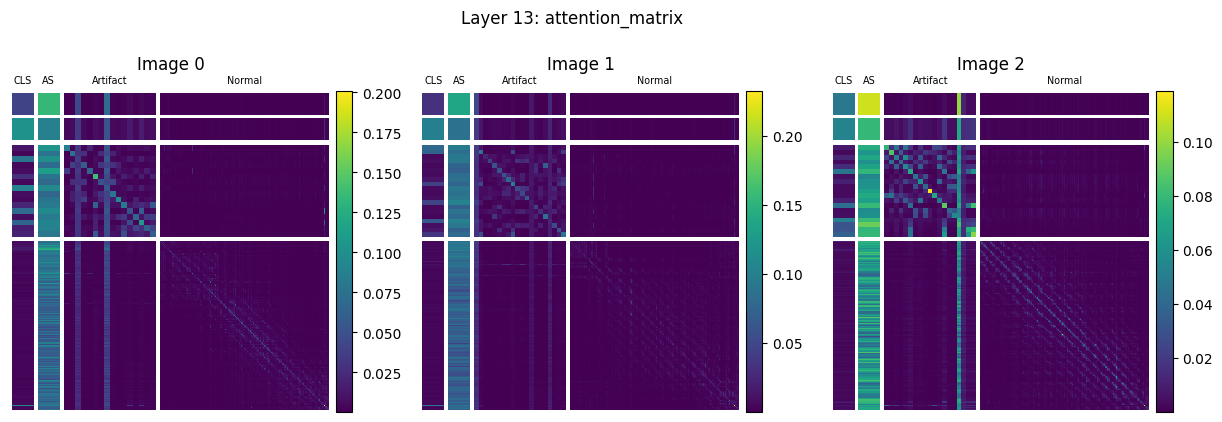

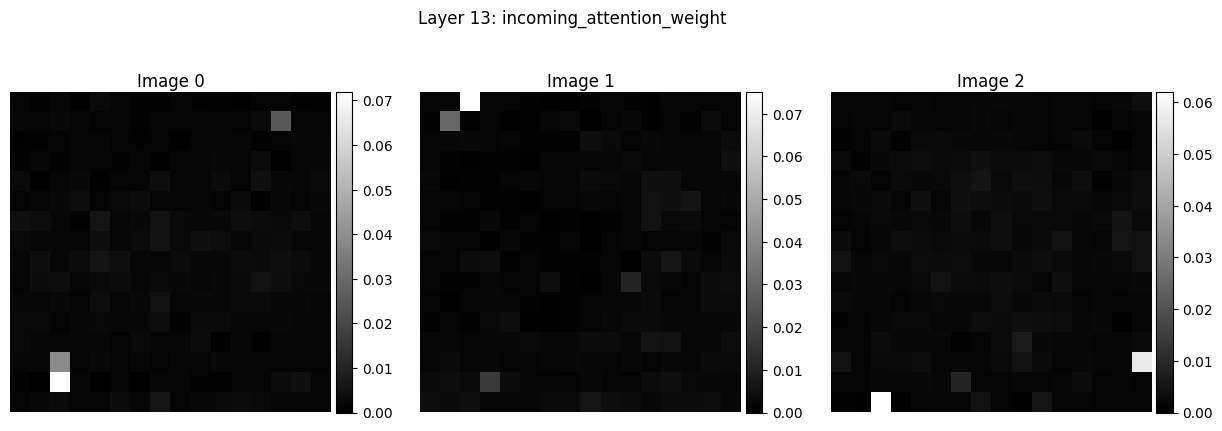

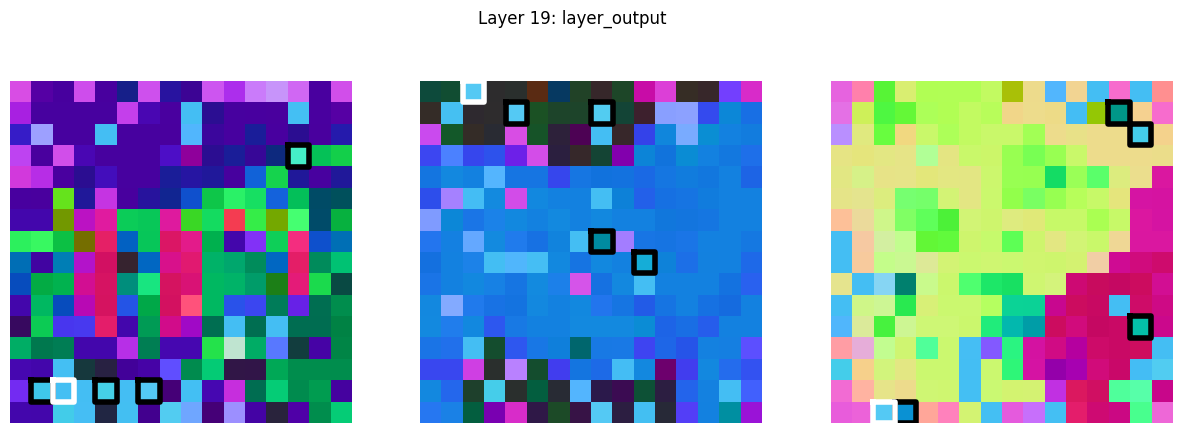

Iteration 5: □□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□


KeyboardInterrupt: 

In [ ]:
%matplotlib inline
from core.attention_sink import mask_attention_sink
from core.visualize import (
    num_visualized_images,
    visualize_attention_matrix_per_image_with_masks,
    visualize_features_per_image,
    visualize_incoming_attention_per_image,
)
from modeling.image_features import ImageFeatures


mode = "mask"
mask_layer = 9
cache: List[torch.Tensor] = [
    per_layer_output_dict[layer_idx]["layer_output"]
    for layer_idx in range(mask_layer)
]
stop_layer = detection_layer + 1

cumulative_MA_mask = mta_masks["MA"].clone()
attention_matrix = per_layer_output_dict[detection_layer]["attention_matrix"].to(DEVICE)


plotting_kwargs: Dict[str, Any] = {
    "transform_func": None,
    "per_head": False,
    "rescale_func": lambda t: torch.log2(t + 1),
    "global_cmap": False,
    "cmap_scale": "linear",
    "subsample": 1.0,
    "spacing": 0.1,
    "cmap": "viridis",
}
visualize_attention_matrix_per_image_with_masks(
    detection_layer, attention_matrix, {
        "MA": cumulative_MA_mask,
        "Artifact": mta_masks["Artifact"],
    }, **plotting_kwargs,
)
# visualize_incoming_attention_per_image(detection_layer, attention_matrix, cmap="gray")


it, max_it = 1, float("inf")
convergence = torch.full((batch_size,), False)
while not torch.all(convergence):
    if it > max_it:
        break
    
    s = "".join("\u25A0" if c else "\u25A1" for c in convergence)    
    print("=" * 160)
    print(f"Iteration {it}: {s}")
    print("=" * 160)
    
    torch.set_default_device(DEVICE)

    new_model = OpenCLIPViT(mask_layer, cumulative_MA_mask, mode, cache=cache, stop_layer=stop_layer).to(DEVICE)
    new_monitor = Monitor(new_model, monitor_config)

    new_per_metric_output_dict = new_monitor.reset()
    with torch.no_grad():
        new_output = new_model.forward(images)

    new_per_layer_output_dict: List[TensorDict] = [None] * mask_layer + construct_per_layer_output_dict({
        k: v[mask_layer:]
        for k, v in new_per_metric_output_dict.items()
    })

    torch.set_default_device(OUTPUT_DEVICE)

    # SECTION: Massive token heuristic
    new_attention_matrix = new_per_layer_output_dict[detection_layer]["attention_matrix"].to(DEVICE)
    
    # SECTION: Visualize the attention matrix before and after
    new_MA_mask = mask_attention_sink(new_attention_matrix.to(OUTPUT_DEVICE), masked_tokens=cumulative_MA_mask, verbose=True)
    print(f"\tNumber of masked MAs: {torch.sum(cumulative_MA_mask, dim=1)[:num_visualized_images].tolist()}")
    print(f"\tNumber of new MAs: {torch.sum(new_MA_mask, dim=1)[:num_visualized_images].tolist()}")
    
    visualize_attention_matrix_per_image_with_masks(
        detection_layer, new_attention_matrix, {
            "exclude": cumulative_MA_mask,
            "Artifact": mta_masks["Artifact"],
        }, **plotting_kwargs,
    )

    visualize_attention_matrix_per_image_with_masks(
        detection_layer, new_attention_matrix, {
            "exclude": cumulative_MA_mask,
            "AS": new_MA_mask,
            "Artifact": mta_masks["Artifact"],
        }, **plotting_kwargs,
    )
    visualize_incoming_attention_per_image(detection_layer, new_attention_matrix, cmap="gray", global_cmap=False)

    visualize_features_per_image(features, 19, "layer_output", mta_mask=cumulative_MA_mask, highlight=torch.argwhere(einops.rearrange(
        new_MA_mask[:, ImageFeatures.image_indices],
        "b (h w) -> b h w", h=ImageFeatures.H, w=ImageFeatures.W,
    )))
    
    # SECTION: Update the cumulative MA mask with the new attention sinks
    cumulative_MA_mask = cumulative_MA_mask + new_MA_mask
    it += 1
    
    # SECTION: Check convergence
    convergence = torch.sum(new_MA_mask, dim=1) == 0

raise Exception()